# Equação da onda em uma barra finita

Podemos usar as células abaixo para plotar soluções da equação da onda em uma barra finita de comprimento L

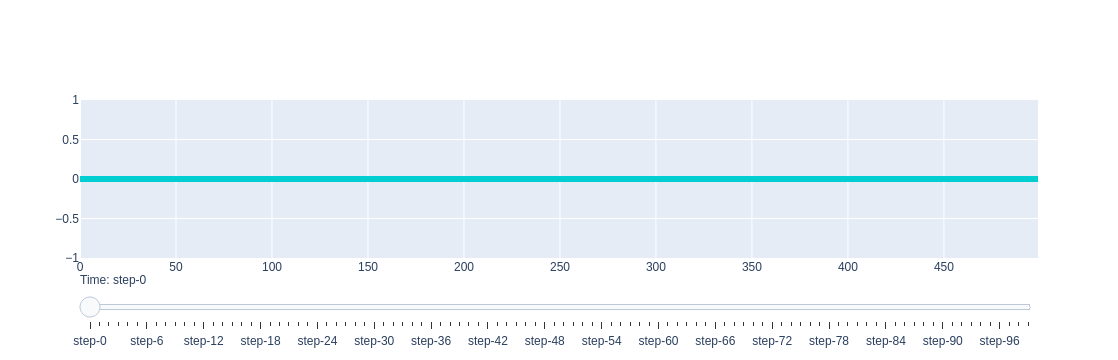

In [7]:
import numpy as np
import plotly.graph_objects as go

#Temperatura zero nas extremidades - série de senos
#Isolada nas extremidades - série de cossenos



#velocidade de propagação
c = 1


#comprimento da barra
L = 4

#número de cosenos e senos na série 
num_termos = 20

# variável do comprimento

x = np.linspace(0,L,500)

# variável do tempo em segundos
t_max = 10
t = np.linspace(0,t_max,100)

#posição inicial
yy = 0*x#np.heaviside(L/2-x,1)*(x)*2/L + np.heaviside(x-L/2,1)*(L-x)*2/L

#velocidade inicial
zz = np.heaviside(L/2-x,1)*(x)*2/L + np.heaviside(x-L/2,1)*(L-x)*2/L#0*x

# a0 inicial da série
a0 = 0

'''
def an(n):
    value = 0
    return value
#'''

#""" an calculado pela máquina - coloque # no início dessa linha para habilitar
def an(n):
    val = yy*np.sin(n*np.pi*x/L)
    value = val.sum()/val.size
    if n==0:
        value=value
    else:
        value=value*2
    return value
a0=an(0)
#"""

'''   
def bn(n):
    value = 0#(8/(n**2*np.pi**2))*np.sin(n*np.pi/2)
    return value
#'''


#""" bn calculado pela máquina - coloque # no início dessa linha para habilitar
def bn(n):
    val = zz*np.sin(n*np.pi*x/L)
    return val.sum()/val.size*2*L/c/np.pi/n
#"""

N=20

def ff(x, tt, N):
    len_x=len(x)
    fun = np.zeros(len_x)
    fun=fun
    for i in range(1,N+1):
        for j in range(len_x):
            fun[j] = fun[j]+(an(i)*np.cos(c*i*np.pi*tt/L)+bn(i)*np.sin(c*i*np.pi*tt/L))*np.sin(i*np.pi*x[j]/L)
    return fun

# Create figure
ymin = -1 #mínimo para eixo y
ymax = 1 #máximo para eixo y
fig = go.Figure(layout_yaxis_range=[ymin, ymax])


# Add traces, one for each slider step
for step in np.arange(0, t_max, 0.1):
    trace=go.Scatter(
            visible=False,
            line=dict(color="#00CED1", width=6),
            name="𝜈 = " + str(step),
            y = ff(x,step,N),
        )
    fig.add_trace(
        trace)

# Make 10th trace visible
fig.data[0].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": "Time: " + str(i/10)}],  # layout attribute
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Time: "},
    pad={"t": 10},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()


In [2]:
%%html
<iframe style="margin-top:0px;margin-left:-20px;" src="https://python-fiddle.com/" width="1200" height="600"></iframe>